# Feature Store de Telemetria — `datasets/D*`

Este notebook reconstrói, para **cada conjunto de dados** em `datasets/D*`, a
mesma *feature store* documentada em `Feature_Store_Telemetria.ipynb`. A
diferença está exclusivamente na origem da banda: os relatórios do protótipo
(`prototipo/relatorios`) produzem um `banda_raw_rota_*.csv` por rota, enquanto
cada conjunto em `datasets/` grava um único `banda.bwm`, com o `bwm-ng`
monitorando de uma só vez todas as interfaces do experimento (roteadores e
hosts). `feature_store/pipeline.py` ganhou, para este caso,
`ingerir_banda_arquivo_unico`: filtra apenas as interfaces atravessadas por
alguma rota e replica cada leitura para as rotas que a compartilham — o mesmo
efeito de `ingerir_banda`, partindo de uma fonte diferente.

## Conjuntos processados

| dataset | descrição |
|---|---|
| `D1`, `D1b` | linha de base, sem tráfego de fundo |
| `D2`, `D2b` | tráfego de fundo constante |
| `D3`, `D3b` | tráfego de fundo com um fluxo iperf longo |
| `D4`, `D4b` | tráfego de fundo com múltiplos fluxos iperf concorrentes |

`D3a` e `D4a` foram excluídos: contêm apenas o CSV largo de latência de uma
coleta secundária, sem `eventos.txt`, `banda.bwm`, `rotas.txt` ou `config.json`
— não há como reconstruir a store a partir deles.

## Saída

Para cada dataset `D`, a store é persistida em `feature_store/data/D/`, nos
mesmos dois layouts do notebook de referência (longo em `csv/`, largo
compatível com `datasets/D*` em `csv_ml/`). As tabelas em memória de todos os
datasets ficam disponíveis ao final em `resultados`, indexadas pelo nome do
dataset.

## 1. Importação

Reaproveita a mesma lógica de localização da raiz do projeto usada no notebook
de referência, necessária porque os caminhos relativos empregados
(`datasets/D*`) dependem do diretório de inicialização do kernel.

In [37]:
import os
import sys
from pathlib import Path


def raiz_do_projeto(marcadores=('prototipo', 'feature_store', 'datasets')):
    candidatos = [Path.cwd(), *Path.cwd().parents]
    for candidato in candidatos:
        if all((candidato / marcador).is_dir() for marcador in marcadores):
            return candidato
    raise RuntimeError(
        f'raiz do projeto não encontrada a partir de {Path.cwd()}. '
        f'Esperado um diretório contendo {marcadores}.'
    )


RAIZ = raiz_do_projeto()
os.chdir(RAIZ)
if str(RAIZ / 'feature_store') not in sys.path:
    sys.path.insert(0, str(RAIZ / 'feature_store'))

print(f'raiz do projeto : {RAIZ}')
print(f'interpretador   : {sys.executable}')
print(f'python          : {sys.version.split()[0]}')

raiz do projeto : /Users/pamella.martins/mestrado/dissertacao/path-aware-datasets
interpretador   : /Users/pamella.martins/mestrado/dissertacao/path-aware-datasets/.venv/bin/python
python          : 3.14.0


In [38]:
import glob

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import pipeline as fs

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 80)

print(f'pandas {pd.__version__} | numpy {np.__version__}')

pandas 3.0.5 | numpy 2.5.2


## 2. Descoberta dos datasets

Um dataset é elegível quando dispõe simultaneamente de `banda.bwm`,
`eventos.txt`, `rotas.txt` e `config.json` — os quatro insumos exigidos por
`fs.construir`.

In [39]:
def dataset_elegivel(pasta):
    exigidos = ['banda.bwm', 'eventos.txt', 'rotas.txt', 'config.json']
    return all(os.path.exists(os.path.join(pasta, arquivo)) for arquivo in exigidos)


todas_as_pastas = sorted(glob.glob('datasets/D*'))
datasets = [os.path.basename(p) for p in todas_as_pastas if dataset_elegivel(p)]
descartados = [os.path.basename(p) for p in todas_as_pastas if not dataset_elegivel(p)]

print(f"datasets elegíveis  ({len(datasets)}): {datasets}")
print(f"datasets descartados ({len(descartados)}): {descartados}")

datasets elegíveis  (8): ['D1', 'D1b', 'D2', 'D2b', 'D3', 'D3b', 'D4', 'D4b']
datasets descartados (2): ['D3a', 'D4a']


## 3. Construção da store por dataset

`fs.construir` recebe `arquivo_banda` apontando para o `banda.bwm` do dataset,
o que roteia a ingestão para `ingerir_banda_arquivo_unico` em vez de
`ingerir_banda`. `pasta_relatorios` e `caminho_config` apontam para a própria
pasta do dataset, de onde vêm `eventos.txt`, `rotas.txt` e `config.json`.

A tolerância de separação de execuções (`gap_maximo_s`) é maior que o padrão
usado em `prototipo/relatorios`: o `banda.bwm` acumula, em uma única coleta
contínua, lacunas isoladas de 1–2 s por amostras perdidas do `bwm-ng`, que a
tolerância padrão de 1 s fragmentaria indevidamente em execuções distintas.
`inferir_alinhamento` já aplica 5 s automaticamente quando `arquivo_banda` é
informado.

In [40]:
resultados = {}
falhas = {}

for dataset in datasets:
    pasta = f'datasets/{dataset}'
    try:
        resultado = fs.construir(
            pasta_relatorios=pasta,
            caminho_config=f'{pasta}/config.json',
            pasta_destino=f'feature_store/data/{dataset}',
            arquivo_banda=f'{pasta}/banda.bwm',
        )
        resultados[dataset] = resultado
    except Exception as erro:
        falhas[dataset] = erro

print(f"{'dataset':8s} {'residuo_s':>9s} {'registros':>10s} {'rotas':>6s} {'lat. preenchida':>16s}")
print('-' * 60)
for dataset, resultado in resultados.items():
    view = resultado['view']
    al = resultado['alinhamento']
    print(f"{dataset:8s} {al['residuo_s']:9.1f} {len(view):10d} "
          f"{view.rota_id.nunique():6d} {view.latencia_ms.notna().sum():7d}/{len(view):<7d}")

if falhas:
    print()
    print("falhas:")
    for dataset, erro in falhas.items():
        print(f"  {dataset}: {erro}")

dataset  residuo_s  registros  rotas  lat. preenchida
------------------------------------------------------------
D1             0.0      14390      4   14386/14390  
D1b            0.0      14380      4   14376/14380  
D2             0.0      14634      4   14630/14634  
D2b            0.0      14580      4   14576/14580  
D3             0.0      14644      4   14640/14644  
D3b            0.0      14626      4   14622/14626  
D4             0.0      15398      4   15394/15398  
D4b            0.0      15066      4   15062/15066  


## 4. Persistência

`fs.construir` já persiste cada store em `feature_store/data/<dataset>/`
(parâmetro `pasta_destino`), nos mesmos dois layouts do notebook de
referência. A célula seguinte apenas lista o que foi gravado.

In [41]:
for dataset in resultados:
    pasta = f'feature_store/data/{dataset}'
    arquivos = sorted(glob.glob(f'{pasta}/csv/*.csv') + glob.glob(f'{pasta}/csv_ml/*'))
    total_bytes = sum(os.path.getsize(a) for a in arquivos)
    print(f"{dataset}: {len(arquivos)} arquivos, {total_bytes:,} bytes em {pasta}/")

D1: 8 arquivos, 11,518,776 bytes em feature_store/data/D1/
D1b: 8 arquivos, 11,363,168 bytes em feature_store/data/D1b/
D2: 8 arquivos, 12,453,152 bytes em feature_store/data/D2/
D2b: 8 arquivos, 12,286,148 bytes em feature_store/data/D2b/
D3: 8 arquivos, 12,516,648 bytes em feature_store/data/D3/
D3b: 8 arquivos, 12,296,927 bytes em feature_store/data/D3b/
D4: 8 arquivos, 13,285,272 bytes em feature_store/data/D4/
D4b: 8 arquivos, 13,032,050 bytes em feature_store/data/D4b/


## 4.1 Arquivos de output e significado das features

### Arquivos gerados por dataset

Para cada `feature_store/data/<DATASET>/`, o pipeline grava dois layouts:

**Layout longo** (`csv/`) — um arquivo por feature group, grão explícito na chave:

| arquivo | grão | conteúdo |
|---|---|---|
| `fg_latencia.csv` | (run, rota, ts) | RTT medido por ping |
| `fg_banda_interface.csv` | (run, rota, interface, ts) | taxa e utilização por interface |
| `fg_banda_rota.csv` | (run, rota, ts) | gargalo e agregados do caminho |
| `consolidado.csv` | (run, rota, ts) | junção, features de janela, deltas e alvo — a tabela principal |
| `dim_rota.csv` | (rota) | atributos fixos do caminho (dimensão) |

**Layout largo** (`csv_ml/`) — compatível com `datasets/D*`, uma coluna por rota:

| arquivo | conteúdo |
|---|---|
| `latencia_rotas_h1_h6.csv` | latência (ms) de cada rota, uma coluna por rota, indexado por `timestamp` |
| `banda_rotas_h1_h6.csv` | gargalo (Mbps) de cada rota, mesmo layout |
| `rotulos_h1_h6.txt` | índice (base 1) da rota de menor latência em cada instante |

### Significado das colunas de `consolidado`

**Chaves e identificadores**

| coluna | significado |
|---|---|
| `run_id` | identificador da execução válida dentro do dataset (após resolução do alinhamento) |
| `rota_id` | caminho de rede ao qual a observação pertence (`h11_h61`, `h12_h62`, `h13_h63`, `h14_h64`) |
| `ts_epoch` | instante da observação, em segundos Unix, na escala comum de banda e latência |
| `datetime_utc` | mesmo instante, em formato de data/hora |
| `tempo_relativo_s` | segundos decorridos desde o início da coleta (uso em gráficos, não em junções) |

**Métricas instantâneas**

| coluna | significado |
|---|---|
| `latencia_ms` | RTT medido pelo ping naquele segundo; `NaN` quando o ping não respondeu |
| `gargalo_Mbps` | banda disponível na interface mais congestionada do caminho — limita a vazão útil da rota |
| `banda_media_Mbps` | média da banda disponível entre todas as interfaces do caminho |
| `util_max_pct` | maior utilização (%) observada entre as interfaces do caminho |

**Features de janela deslizante** (janelas `micro`=5s, `curta`=15s, `longa`=30s)

| padrão de coluna | significado |
|---|---|
| `latencia_p95_{janela}` | pior latência típica na janela (percentil 95) |
| `latencia_jitter_{janela}` | desvio padrão da latência na janela — instabilidade |
| `latencia_media_{janela}` | latência média suavizada na janela |
| `gargalo_min_{janela}` | pior gargalo observado na janela |
| `banda_media_{janela}` | banda média disponível na janela |
| `utilizacao_media_{janela}` | utilização média (0–1) na janela |

**Deltas e features cruzadas**

| coluna | significado |
|---|---|
| `latencia_delta_micro_longa` | tendência: latência média recente (5s) menos a média de contexto (30s) |
| `banda_delta_micro_longa` | severidade do gargalo atual: pior gargalo recente (5s) sobre banda média de contexto (30s) |
| `bdp` | *Bandwidth-Delay Product* (`gargalo_Mbps × latencia_ms`) — volume estimado de dados em trânsito |

**Alvo**

| coluna | significado |
|---|---|
| `melhor_rota` | índice (base 1) da rota de menor latência naquele instante; **função determinística da latência** (vazamento de rótulo, ver Seção 8) |

**Dimensão da rota** (`dim_rota`, incluída apenas com `incluir_dim_rota=True`)

| coluna | significado |
|---|---|
| `caminho` | sequência de switches/hosts percorrida pela rota |
| `n_links_sw` | número de enlaces inter-switch (proxy de número de saltos) |
| `atraso_cfg_ms` | RTT teórico configurado no TCLink para o caminho |

A coluna adicional `dataset_id`, presente apenas no resultado de
`get_features_todos` (Seção 7), identifica de qual dataset (`D1`, `D2` etc.)
cada linha se origina — não existe nos CSVs individuais de cada store.

## 5. Verificação

Reaplica, para cada dataset, as verificações estruturais do notebook de
referência (Seção 10): ausência de colunas integralmente nulas, contagem
consistente de rotas e concentração dos valores ausentes de latência na
inicialização do ping.

In [42]:
for dataset, resultado in resultados.items():
    view = resultado['view']

    assert not [c for c in view.columns if view[c].isna().all()], \
        f'{dataset}: há coluna integralmente nula'

    # As contagens por rota podem diferir por poucos segundos: cada rota tem
    # sua propria janela de amostragem de banda, e amostras isoladas do
    # bwm-ng podem faltar em uma interface e nao em outra. Verifica-se
    # proximidade, nao igualdade estrita.
    contagens = view.rota_id.value_counts()
    dispersao = contagens.max() - contagens.min()
    assert dispersao <= 10, \
        f'{dataset}: rotas com contagens muito diferentes de registros: {contagens.to_dict()}'

    ausentes = view[view.latencia_ms.isna()]
    if len(ausentes):
        # As amostras sem latência devem concentrar-se no início da coleta
        # (inicialização do ping), não espalhadas ao longo da série
        limite = view.ts_epoch.min() + 3
        assert ausentes.ts_epoch.max() <= limite, \
            f'{dataset}: valores ausentes de latência fora da inicialização do ping'

print(f"verificações estruturais aprovadas para {len(resultados)} datasets")

verificações estruturais aprovadas para 8 datasets


## 6. Visualização de validação

Gargalo e latência ao longo do tempo, lado a lado para todos os datasets, como
checagem visual de que o alinhamento e a agregação produziram séries
coerentes com o cenário de cada coleta (linha de base, tráfego de fundo
constante ou fluxos iperf concorrentes).

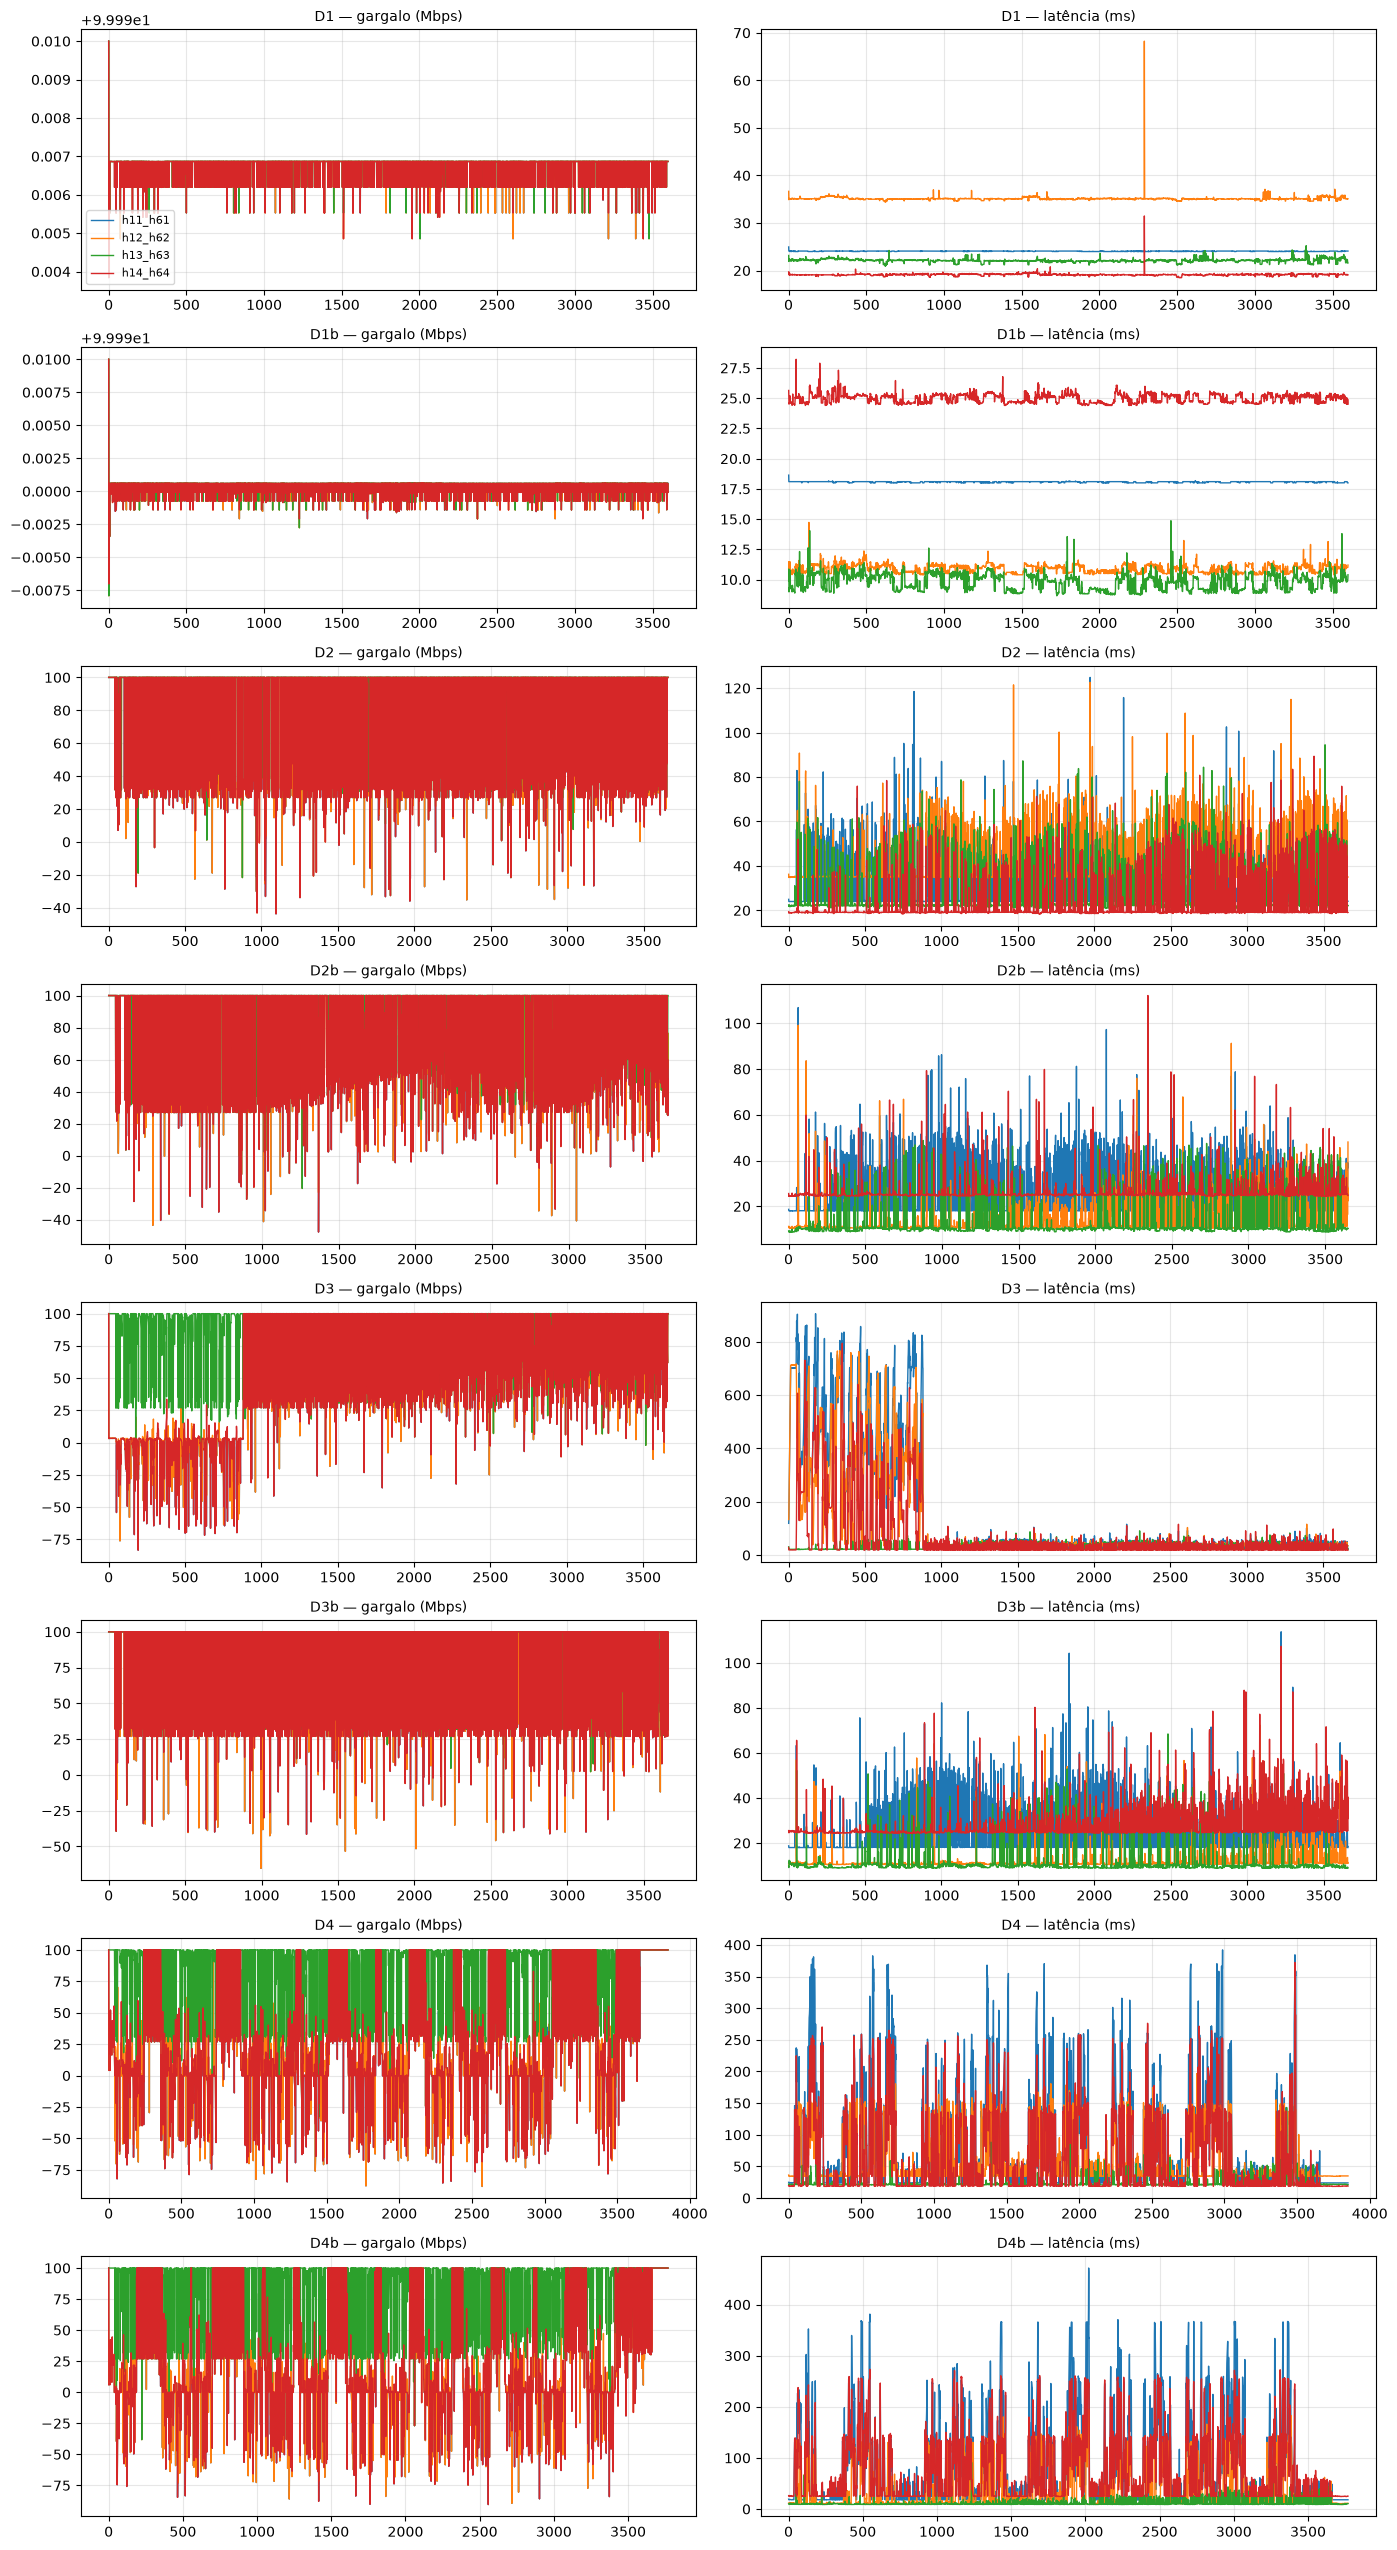

In [43]:
n = len(resultados)
fig, eixos = plt.subplots(n, 2, figsize=(14, 3.2 * n), squeeze=False)

for linha, (dataset, resultado) in enumerate(resultados.items()):
    view = resultado['view']
    ax_banda, ax_latencia = eixos[linha]

    for rota, grupo in view.groupby('rota_id'):
        ax_banda.plot(grupo.tempo_relativo_s, grupo.gargalo_Mbps, label=rota, linewidth=1)
        ax_latencia.plot(grupo.tempo_relativo_s, grupo.latencia_ms, label=rota, linewidth=1)

    ax_banda.set_title(f'{dataset} — gargalo (Mbps)', fontsize=10)
    ax_latencia.set_title(f'{dataset} — latência (ms)', fontsize=10)
    ax_banda.grid(alpha=0.3)
    ax_latencia.grid(alpha=0.3)
    if linha == 0:
        ax_banda.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

## 7. Consulta consolidada entre datasets

Como cada dataset é persistido em sua própria pasta, `get_features` é chamado
uma vez por dataset e as tabelas resultantes são concatenadas com uma coluna
adicional `dataset_id`, permitindo comparações entre coletas sem misturar
`run_id` (que é local a cada store).

In [44]:
def get_features_todos(datasets=resultados.keys(), **kwargs):
    partes = []
    for dataset in datasets:
        parte = fs.get_features(pasta_origem=f'feature_store/data/{dataset}', **kwargs)
        parte.insert(0, 'dataset_id', dataset)
        partes.append(parte)
    return pd.concat(partes, ignore_index=True)


completo = get_features_todos()
print(f"conjunto completo: {completo.shape[1]} colunas, {len(completo)} registros")
print(f"datasets: {sorted(completo.dataset_id.unique())}")
completo.head()

conjunto completo: 32 colunas, 117718 registros
datasets: ['D1', 'D1b', 'D2', 'D2b', 'D3', 'D3b', 'D4', 'D4b']


,dataset_id,run_id,rota_id,ts_epoch,datetime_utc,tempo_relativo_s,gargalo_Mbps,banda_media_Mbps,util_max_pct,latencia_ms,latencia_p95_micro_5s,latencia_jitter_micro_5s,latencia_media_micro_5s,gargalo_min_micro_5s,banda_media_micro_5s,utilizacao_media_micro_5s,latencia_p95_curta_15s,latencia_jitter_curta_15s,latencia_media_curta_15s,gargalo_min_curta_15s,banda_media_curta_15s,utilizacao_media_curta_15s,latencia_p95_longa_30s,latencia_jitter_longa_30s,latencia_media_longa_30s,gargalo_min_longa_30s,banda_media_longa_30s,utilizacao_media_longa_30s,latencia_delta_micro_longa,bdp,banda_delta_micro_longa,melhor_rota
0,D1,0,h11_h61,1764165622,2025-11-26 14:00:22,0,100.00000,100.000000,0.00000,NaN,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,1.000000,<NA>
1,D1,0,h12_h62,1764165622,2025-11-26 14:00:22,0,100.00000,100.000000,0.00000,NaN,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,1.000000,<NA>
2,D1,0,h13_h63,1764165622,2025-11-26 14:00:22,0,100.00000,100.000000,0.00000,NaN,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,1.000000,<NA>
3,D1,0,h14_h64,1764165622,2025-11-26 14:00:22,0,100.00000,100.000000,0.00000,NaN,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,1.000000,<NA>
4,D1,0,h11_h61,1764165623,2025-11-26 14:00:23,1,99.99384,99.994251,0.00616,24.962602,24.962602,NaN,24.962602,99.99384,99.997125,0.000031,24.962602,NaN,24.962602,99.99384,99.997125,0.000031,24.962602,NaN,24.962602,99.99384,99.997125,0.000031,0.0,2496.106453,0.999967,4


## 8. Análise de feature importance

Reaproveita o ferramental de `Análise_de_modelos_de_ML_para_previsão_de_caminhos.ipynb`
(RandomForest + `sklearn`) para estimar a importância relativa de cada feature
da store na previsão de `melhor_rota`, combinando os dois métodos usuais:

- **Importância por impureza (MDI)**: `feature_importances_` do RandomForest,
  calculada durante o treino a partir da redução média de impureza (Gini) em
  cada split. É rápida, mas enviesada a favor de features com muitos valores
  distintos e não reflete diretamente o desempenho do modelo.
- **Importância por permutação**: embaralha cada coluna (uma de cada vez) no
  conjunto de teste e mede a queda de acurácia. É mais confiável — reflete o
  impacto real na métrica escolhida — mas mais cara computacionalmente.

Como `melhor_rota` é função determinística de `latencia_ms` (ver seção de
Limitações), as colunas derivadas de latência dominam a análise por
construção. A célula de preparação dos dados por isso oferece a opção de
excluir o grupo `latencia_*` para revelar a importância relativa **dentro**
das features de banda/gargalo — a pergunta mais interessante do ponto de
vista de um modelo que não tenha acesso direto à latência da rota candidata.

Além da análise geral (todos os datasets combinados), a seção também repete o
cálculo **separadamente por cenário de tráfego** (`D1`/`D1b`, `D2`/`D2b`,
`D3`/`D3b`, `D4`/`D4b`), permitindo verificar se a importância relativa das
features muda conforme o regime de congestionamento de fundo.

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

RANDOM_STATE = 1234

### Preparação dos dados

Usa o conjunto consolidado de todos os datasets (`completo`, seção 7), com
`melhor_rota` como alvo. Colunas identificadoras/temporais e as próprias
colunas de origem do alvo (que definiriam `melhor_rota` por construção, se
mantidas por rota) são descartadas; linhas sem alvo (`melhor_rota` nulo, por
falha de ping em alguma rota naquele instante) são removidas.

`EXCLUIR_LATENCIA` controla se as features de latência entram na análise —
mantenha `True` para focar na importância relativa das features de banda.

In [46]:
EXCLUIR_LATENCIA = True

COLUNAS_NAO_FEATURE = {
    'dataset_id', 'run_id', 'rota_id', 'ts_epoch', 'datetime_utc',
    'tempo_relativo_s', 'melhor_rota',
}

base = completo.dropna(subset=['melhor_rota']).copy()

candidatas = [c for c in base.columns if c not in COLUNAS_NAO_FEATURE]
if EXCLUIR_LATENCIA:
    candidatas = [c for c in candidatas if not c.startswith('latencia_')
                  and c not in ('bdp',)]

# Descarta colunas totalmente nulas para o corte atual (ex.: features de janela
# sem amostras suficientes no início de cada run)
candidatas = [c for c in candidatas if base[c].notna().any()]

X_fi = base[candidatas].fillna(base[candidatas].median(numeric_only=True))
y_fi = base['melhor_rota'].astype(int)

print(f"features candidatas: {len(candidatas)}")
print(f"registros: {len(X_fi)}")
print(f"classes (rotas): {sorted(y_fi.unique())}")

features candidatas: 13
registros: 117668
classes (rotas): [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### Treino do RandomForest

Split treino/teste estratificado (80/20), igual ao usado no notebook de
referência, para permitir tanto a importância por impureza (calculada no
treino) quanto a importância por permutação (calculada no teste, para não
inflar a métrica com overfitting).

In [47]:
X_train_fi, X_test_fi, y_train_fi, y_test_fi = train_test_split(
    X_fi, y_fi, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fi
)

modelo_fi = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
modelo_fi.fit(X_train_fi, y_train_fi)

acuracia_fi = modelo_fi.score(X_test_fi, y_test_fi)
print(f"acurácia no teste: {acuracia_fi:.4f}")

acurácia no teste: 0.8455


### Importância por impureza (MDI)

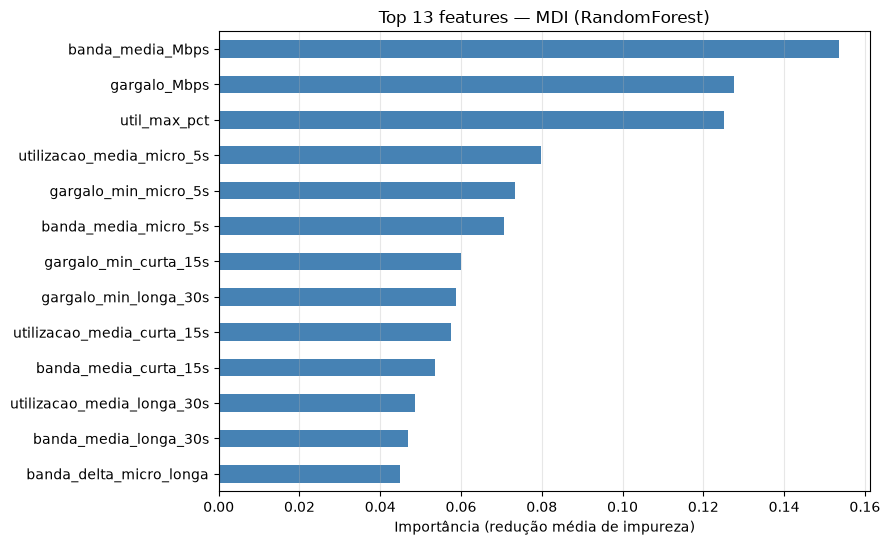

banda_media_Mbps              0.153645
gargalo_Mbps                  0.127600
util_max_pct                  0.125040
utilizacao_media_micro_5s     0.079743
gargalo_min_micro_5s          0.073246
banda_media_micro_5s          0.070690
gargalo_min_curta_15s         0.059987
gargalo_min_longa_30s         0.058772
utilizacao_media_curta_15s    0.057460
banda_media_curta_15s         0.053506
utilizacao_media_longa_30s    0.048695
banda_media_longa_30s         0.046801
banda_delta_micro_longa       0.044814
dtype: float64

In [48]:
importancia_mdi = pd.Series(modelo_fi.feature_importances_, index=candidatas)
importancia_mdi = importancia_mdi.sort_values(ascending=False)

top_n = min(20, len(importancia_mdi))
fig, ax = plt.subplots(figsize=(9, 0.35 * top_n + 1))
importancia_mdi.head(top_n).iloc[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Importância (redução média de impureza)')
ax.set_title(f'Top {top_n} features — MDI (RandomForest)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

importancia_mdi.head(top_n)

### Importância por permutação

Calculada sobre o conjunto de teste, com 10 repetições por feature para
estimar a variabilidade (barras de erro = desvio padrão entre repetições).

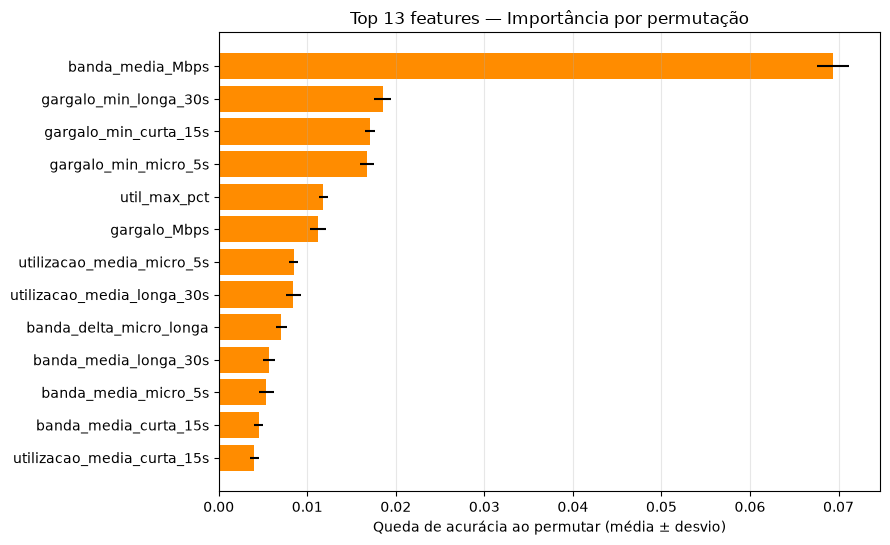

banda_media_Mbps              0.069325
gargalo_min_longa_30s         0.018518
gargalo_min_curta_15s         0.017099
gargalo_min_micro_5s          0.016742
util_max_pct                  0.011830
gargalo_Mbps                  0.011231
utilizacao_media_micro_5s     0.008460
utilizacao_media_longa_30s    0.008435
banda_delta_micro_longa       0.007075
banda_media_longa_30s         0.005660
banda_media_micro_5s          0.005367
banda_media_curta_15s         0.004525
utilizacao_media_curta_15s    0.004003
dtype: float64

In [49]:
resultado_perm = permutation_importance(
    modelo_fi, X_test_fi, y_test_fi,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=1
)

importancia_perm = pd.Series(resultado_perm.importances_mean, index=candidatas)
desvio_perm = pd.Series(resultado_perm.importances_std, index=candidatas)
ordem_perm = importancia_perm.sort_values(ascending=False)

top_n = min(20, len(ordem_perm))
fig, ax = plt.subplots(figsize=(9, 0.35 * top_n + 1))
ax.barh(
    ordem_perm.head(top_n).index[::-1],
    ordem_perm.head(top_n).iloc[::-1],
    xerr=desvio_perm.reindex(ordem_perm.head(top_n).index).iloc[::-1],
    color='darkorange',
)
ax.set_xlabel('Queda de acurácia ao permutar (média ± desvio)')
ax.set_title(f'Top {top_n} features — Importância por permutação')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

ordem_perm.head(top_n)

### Comparação entre os dois métodos

Concorda quando a mesma feature aparece bem posicionada nos dois rankings;
diverge tipicamente para features de alta cardinalidade, que a MDI tende a
supervalorizar frente ao real impacto na acurácia.

In [50]:
comparacao_fi = pd.DataFrame({
    'mdi': importancia_mdi,
    'permutacao': importancia_perm,
}).sort_values('permutacao', ascending=False)

comparacao_fi['rank_mdi'] = comparacao_fi['mdi'].rank(ascending=False).astype(int)
comparacao_fi['rank_permutacao'] = comparacao_fi['permutacao'].rank(ascending=False).astype(int)

comparacao_fi.head(15)

,mdi,permutacao,rank_mdi,rank_permutacao
banda_media_Mbps,0.153645,0.069325,1,1
gargalo_min_longa_30s,0.058772,0.018518,8,2
gargalo_min_curta_15s,0.059987,0.017099,7,3
gargalo_min_micro_5s,0.073246,0.016742,5,4
util_max_pct,0.125040,0.011830,3,5
gargalo_Mbps,0.127600,0.011231,2,6
utilizacao_media_micro_5s,0.079743,0.008460,4,7
utilizacao_media_longa_30s,0.048695,0.008435,11,8
banda_delta_micro_longa,0.044814,0.007075,13,9
banda_media_longa_30s,0.046801,0.005660,12,10


### Feature importance por cenário

A análise anterior combina todos os datasets — mas cada par (`D1`/`D1b`,
`D2`/`D2b`, `D3`/`D3b`, `D4`/`D4b`) representa um cenário de tráfego de fundo
distinto (ver Seção "Conjuntos processados"), e a importância relativa das
features pode variar conforme o regime de congestionamento. Esta seção repete
o treino e a importância por permutação **separadamente para cada cenário**,
usando o mesmo conjunto de 13 features de banda/gargalo (sem latência), para
permitir comparar se, por exemplo, o gargalo importa mais sob tráfego
concorrente (`D4`) do que na linha de base (`D1`).

In [51]:
CENARIOS = {
    'D1 (baseline)': ['D1', 'D1b'],
    'D2 (tráfego constante)': ['D2', 'D2b'],
    'D3 (iperf longo)': ['D3', 'D3b'],
    'D4 (iperf concorrente)': ['D4', 'D4b'],
}

importancias_por_cenario = {}
importancias_mdi_por_cenario = {}
acuracias_por_cenario = {}

for nome_cenario, datasets_cenario in CENARIOS.items():
    base_c = base[base.dataset_id.isin(datasets_cenario)]
    X_c = base_c[candidatas]
    y_c = base_c['melhor_rota'].astype(int)

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_c, y_c, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c
    )

    modelo_c = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    modelo_c.fit(X_train_c, y_train_c)
    acuracia_c = modelo_c.score(X_test_c, y_test_c)

    resultado_perm_c = permutation_importance(
        modelo_c, X_test_c, y_test_c,
        n_repeats=5, random_state=RANDOM_STATE, n_jobs=1
    )

    importancias_por_cenario[nome_cenario] = pd.Series(
        resultado_perm_c.importances_mean, index=candidatas
    )
    importancias_mdi_por_cenario[nome_cenario] = pd.Series(
        modelo_c.feature_importances_, index=candidatas
    )
    acuracias_por_cenario[nome_cenario] = acuracia_c

    print(f"{nome_cenario:26s} | registros: {len(X_c):6d} | acurácia: {acuracia_c:.4f}")

D1 (baseline)              | registros:  28756 | acurácia: 0.9937
D2 (tráfego constante)     | registros:  29204 | acurácia: 0.8365
D2 (tráfego constante)     | registros:  29204 | acurácia: 0.8365
D3 (iperf longo)           | registros:  29256 | acurácia: 0.8059
D3 (iperf longo)           | registros:  29256 | acurácia: 0.8059
D4 (iperf concorrente)     | registros:  30452 | acurácia: 0.8153
D4 (iperf concorrente)     | registros:  30452 | acurácia: 0.8153


### Comparação entre cenários e resultado geral

Tabela com a importância por permutação de cada feature em cada cenário,
lado a lado com a importância geral (todos os datasets combinados, calculada
anteriormente), ordenada pela importância geral. Isso evidencia tanto
features consistentemente importantes em todos os cenários quanto features
cuja relevância é específica de um regime de tráfego.

In [52]:
comparacao_cenarios = pd.DataFrame(importancias_por_cenario)
comparacao_cenarios['geral (todos os datasets)'] = importancia_perm
comparacao_cenarios = comparacao_cenarios.sort_values('geral (todos os datasets)', ascending=False)

comparacao_cenarios

,D1 (baseline),D2 (tráfego constante),D3 (iperf longo),D4 (iperf concorrente),geral (todos os datasets)
banda_media_Mbps,0.000000e+00,0.160760,0.051504,0.008439,0.069325
gargalo_min_longa_30s,2.220446e-17,0.012566,0.006528,0.034641,0.018518
gargalo_min_curta_15s,1.390821e-04,0.015408,0.007416,0.030504,0.017099
gargalo_min_micro_5s,1.390821e-04,0.027632,0.008886,0.022033,0.016742
util_max_pct,0.000000e+00,0.046259,0.015038,0.013331,0.011830
gargalo_Mbps,0.000000e+00,0.042116,0.012611,0.012543,0.011231
utilizacao_media_micro_5s,6.954103e-05,0.003869,0.002324,0.010212,0.008460
utilizacao_media_longa_30s,0.000000e+00,-0.002431,0.007587,0.015071,0.008435
banda_delta_micro_longa,-1.043115e-04,0.012703,0.004204,0.007683,0.007075
banda_media_longa_30s,1.043115e-04,-0.000034,0.003691,0.014546,0.005660


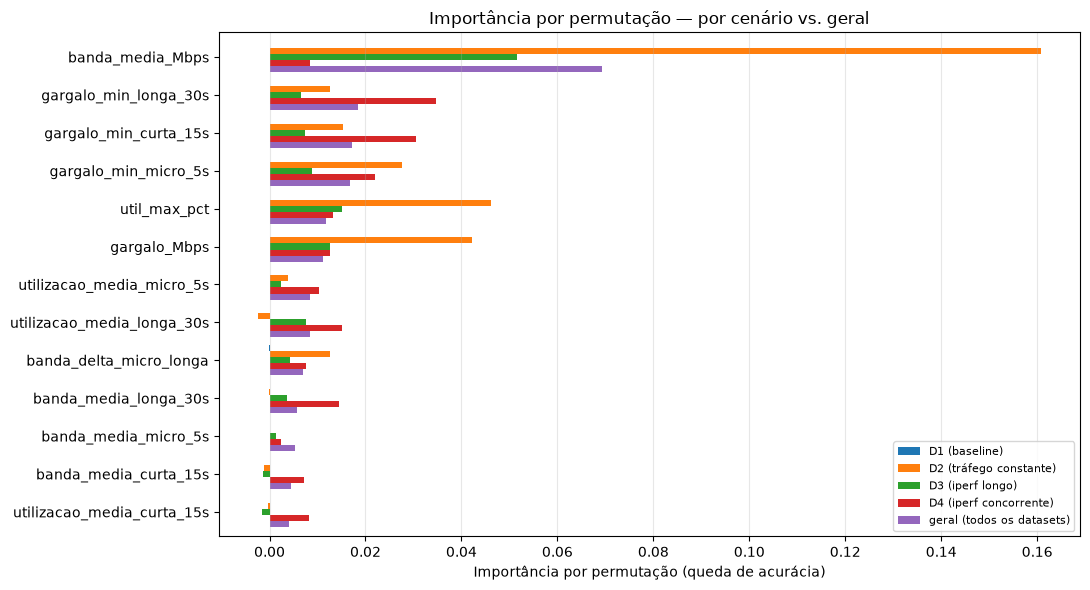

In [53]:
fig, ax = plt.subplots(figsize=(11, 6))
comparacao_cenarios.plot.barh(ax=ax, width=0.8)
ax.set_xlabel('Importância por permutação (queda de acurácia)')
ax.set_title('Importância por permutação — por cenário vs. geral')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### MDI por cenário e resultado geral

Mesma comparação anterior, agora usando a importância por impureza (MDI)
em vez de permutação — permite ver se a divergência entre os dois métodos
observada no resultado geral (Seção 8) também aparece dentro de cada
cenário individualmente.

In [54]:
comparacao_cenarios_mdi = pd.DataFrame(importancias_mdi_por_cenario)
comparacao_cenarios_mdi['geral (todos os datasets)'] = importancia_mdi
comparacao_cenarios_mdi = comparacao_cenarios_mdi.sort_values('geral (todos os datasets)', ascending=False)

comparacao_cenarios_mdi

,D1 (baseline),D2 (tráfego constante),D3 (iperf longo),D4 (iperf concorrente),geral (todos os datasets)
banda_media_Mbps,0.109016,0.189578,0.159877,0.064990,0.153645
gargalo_Mbps,0.083806,0.155942,0.131974,0.080827,0.127600
util_max_pct,0.064172,0.156651,0.126886,0.084140,0.125040
utilizacao_media_micro_5s,0.079591,0.055032,0.058405,0.075412,0.079743
gargalo_min_micro_5s,0.108331,0.069292,0.066009,0.081528,0.073246
banda_media_micro_5s,0.081091,0.050086,0.056763,0.064395,0.070690
gargalo_min_curta_15s,0.064465,0.053666,0.064366,0.089283,0.059987
gargalo_min_longa_30s,0.093930,0.051097,0.060189,0.091909,0.058772
utilizacao_media_curta_15s,0.085510,0.040716,0.054914,0.075555,0.057460
banda_media_curta_15s,0.081415,0.039300,0.051469,0.067467,0.053506


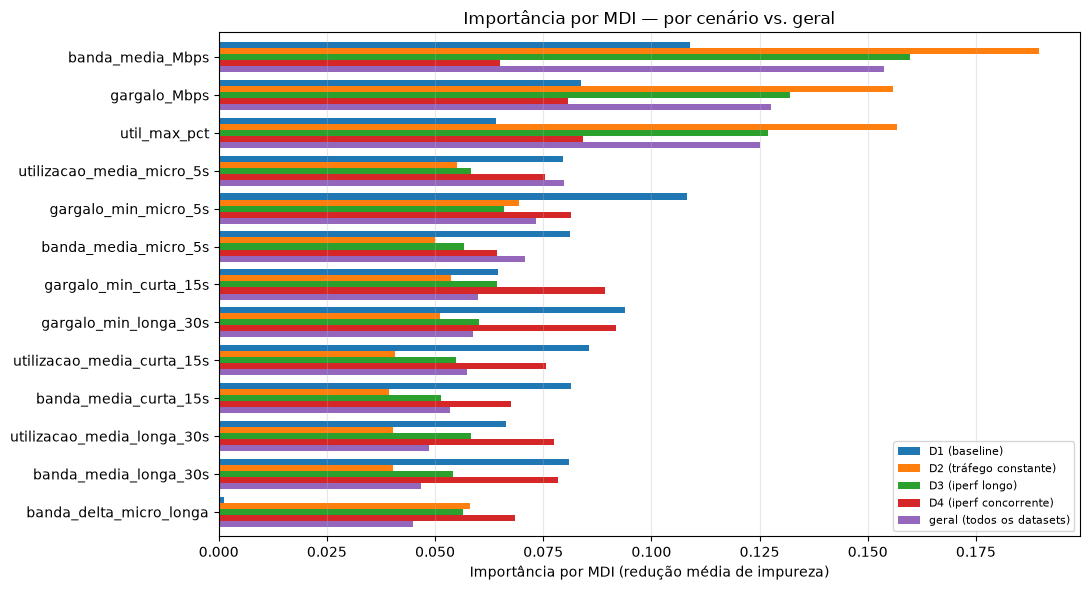

In [55]:
fig, ax = plt.subplots(figsize=(11, 6))
comparacao_cenarios_mdi.plot.barh(ax=ax, width=0.8)
ax.set_xlabel('Importância por MDI (redução média de impureza)')
ax.set_title('Importância por MDI — por cenário vs. geral')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### Acurácia por cenário

A acurácia de cada modelo por cenário, comparada com a acurácia geral obtida
com todos os datasets combinados — indica se a tarefa fica mais fácil ou mais
difícil quando restrita a um único regime de tráfego (menos variação nos
dados, porém menos exemplos de treino).

In [56]:
resumo_acuracia = pd.Series(acuracias_por_cenario)
resumo_acuracia['geral (todos os datasets)'] = acuracia_fi
resumo_acuracia.to_frame('acurácia no teste')

,acurácia no teste
D1 (baseline),0.993741
D2 (tráfego constante),0.836501
D3 (iperf longo),0.805878
D4 (iperf concorrente),0.815301
geral (todos os datasets),0.845543


### Análise complementar incluindo latência

As análises anteriores excluem `latencia_*` e `bdp` deliberadamente, para
evitar o vazamento trivial descrito na Seção 11. Esta subseção repete o
treino **incluindo** essas features, tanto no conjunto geral (todos os
datasets) quanto **separadamente por cenário** (mesmos pares `D1`/`D1b` a
`D4`/`D4b` usados na análise sem latência), para quantificar diretamente o
quanto elas dominam quando presentes, se essa dominância é uniforme entre
cenários, e para confirmar que o exercício de exclusão não é apenas uma
precaução teórica.

In [57]:
candidatas_com_latencia = [c for c in base.columns if c not in COLUNAS_NAO_FEATURE]
candidatas_com_latencia = [c for c in candidatas_com_latencia if base[c].notna().any()]

X_cl = base[candidatas_com_latencia].fillna(base[candidatas_com_latencia].median(numeric_only=True))
y_cl = base['melhor_rota'].astype(int)

X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(
    X_cl, y_cl, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cl
)

modelo_cl = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
modelo_cl.fit(X_train_cl, y_train_cl)

acuracia_cl = modelo_cl.score(X_test_cl, y_test_cl)
print(f"features (com latência): {len(candidatas_com_latencia)}")
print(f"acurácia no teste (geral): {acuracia_cl:.4f}")

# Repete o treino separadamente por cenário, com o mesmo conjunto de features
# (com latência), para verificar se a dominância da latência é uniforme entre
# regimes de tráfego de fundo.
importancias_por_cenario_cl = {}
importancias_mdi_por_cenario_cl = {}
acuracias_por_cenario_cl = {}

print()
for nome_cenario, datasets_cenario in CENARIOS.items():
    base_c = base[base.dataset_id.isin(datasets_cenario)]
    X_c_cl = base_c[candidatas_com_latencia].fillna(
        base_c[candidatas_com_latencia].median(numeric_only=True)
    )
    y_c_cl = base_c['melhor_rota'].astype(int)

    X_train_c_cl, X_test_c_cl, y_train_c_cl, y_test_c_cl = train_test_split(
        X_c_cl, y_c_cl, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c_cl
    )

    modelo_c_cl = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    modelo_c_cl.fit(X_train_c_cl, y_train_c_cl)
    acuracia_c_cl = modelo_c_cl.score(X_test_c_cl, y_test_c_cl)

    resultado_perm_c_cl = permutation_importance(
        modelo_c_cl, X_test_c_cl, y_test_c_cl,
        n_repeats=5, random_state=RANDOM_STATE, n_jobs=1
    )

    importancias_por_cenario_cl[nome_cenario] = pd.Series(
        resultado_perm_c_cl.importances_mean, index=candidatas_com_latencia
    )
    importancias_mdi_por_cenario_cl[nome_cenario] = pd.Series(
        modelo_c_cl.feature_importances_, index=candidatas_com_latencia
    )
    acuracias_por_cenario_cl[nome_cenario] = acuracia_c_cl

    print(f"{nome_cenario:26s} | registros: {len(X_c_cl):6d} | acurácia: {acuracia_c_cl:.4f}")

features (com latência): 25
acurácia no teste (geral): 0.8903

D1 (baseline)              | registros:  28756 | acurácia: 0.9937
D1 (baseline)              | registros:  28756 | acurácia: 0.9937
D2 (tráfego constante)     | registros:  29204 | acurácia: 0.8812
D2 (tráfego constante)     | registros:  29204 | acurácia: 0.8812
D3 (iperf longo)           | registros:  29256 | acurácia: 0.8404
D3 (iperf longo)           | registros:  29256 | acurácia: 0.8404
D4 (iperf concorrente)     | registros:  30452 | acurácia: 0.8639
D4 (iperf concorrente)     | registros:  30452 | acurácia: 0.8639


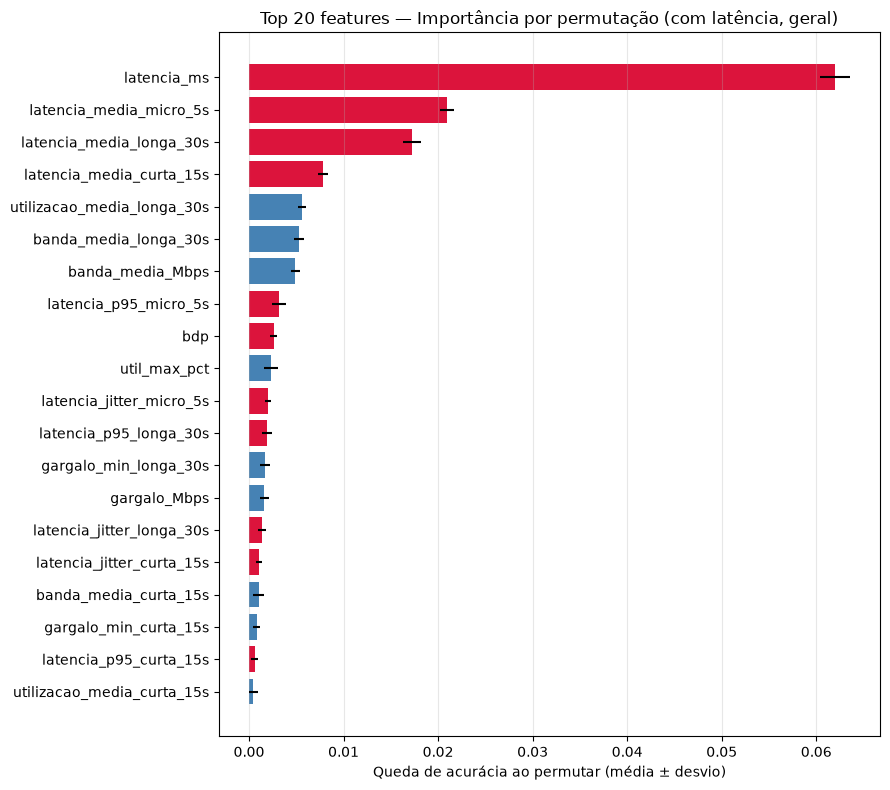

vermelho = feature de latência/bdp | azul = feature de banda/gargalo


latencia_ms                   0.062000
latencia_media_micro_5s       0.020927
latencia_media_longa_30s      0.017277
latencia_media_curta_15s      0.007818
utilizacao_media_longa_30s    0.005588
banda_media_longa_30s         0.005277
banda_media_Mbps              0.004912
latencia_p95_micro_5s         0.003161
bdp                           0.002630
util_max_pct                  0.002337
latencia_jitter_micro_5s      0.001997
latencia_p95_longa_30s        0.001904
gargalo_min_longa_30s         0.001687
gargalo_Mbps                  0.001623
latencia_jitter_longa_30s     0.001385
latencia_jitter_curta_15s     0.001058
banda_media_curta_15s         0.001011
gargalo_min_curta_15s         0.000803
latencia_p95_curta_15s        0.000603
utilizacao_media_curta_15s    0.000446
dtype: float64

In [58]:
resultado_perm_cl = permutation_importance(
    modelo_cl, X_test_cl, y_test_cl,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=1
)

importancia_perm_cl = pd.Series(resultado_perm_cl.importances_mean, index=candidatas_com_latencia)
desvio_perm_cl = pd.Series(resultado_perm_cl.importances_std, index=candidatas_com_latencia)
ordem_perm_cl = importancia_perm_cl.sort_values(ascending=False)

top_n = min(20, len(ordem_perm_cl))
fig, ax = plt.subplots(figsize=(9, 0.35 * top_n + 1))
cores = ['crimson' if c.startswith('latencia_') or c == 'bdp' else 'steelblue'
         for c in ordem_perm_cl.head(top_n).index[::-1]]
ax.barh(
    ordem_perm_cl.head(top_n).index[::-1],
    ordem_perm_cl.head(top_n).iloc[::-1],
    xerr=desvio_perm_cl.reindex(ordem_perm_cl.head(top_n).index).iloc[::-1],
    color=cores,
)
ax.set_xlabel('Queda de acurácia ao permutar (média ± desvio)')
ax.set_title(f'Top {top_n} features — Importância por permutação (com latência, geral)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("vermelho = feature de latência/bdp | azul = feature de banda/gargalo")
ordem_perm_cl.head(top_n)

### Comparação entre cenários e resultado geral (com latência)

Mesmo formato da comparação por cenário sem latência, agora com o conjunto
de 25 features (banda/gargalo + latência/bdp), lado a lado com o resultado
geral.

In [59]:
comparacao_cenarios_cl = pd.DataFrame(importancias_por_cenario_cl)
comparacao_cenarios_cl['geral (todos os datasets)'] = importancia_perm_cl
comparacao_cenarios_cl = comparacao_cenarios_cl.sort_values('geral (todos os datasets)', ascending=False)

comparacao_cenarios_cl

,D1 (baseline),D2 (tráfego constante),D3 (iperf longo),D4 (iperf concorrente),geral (todos os datasets)
latencia_ms,-0.000035,0.075638,0.050205,0.063307,0.062000
latencia_media_micro_5s,0.000104,0.006163,0.002051,0.026826,0.020927
latencia_media_longa_30s,0.000243,0.029961,0.009296,0.008439,0.017277
latencia_media_curta_15s,0.000243,0.004657,0.005639,0.007913,0.007818
utilizacao_media_longa_30s,-0.000174,0.005547,0.002802,0.004761,0.005588
banda_media_longa_30s,0.000174,0.004177,0.003213,0.004794,0.005277
banda_media_Mbps,0.000000,0.033248,0.022215,0.002463,0.004912
latencia_p95_micro_5s,-0.000035,-0.000068,0.004477,0.002758,0.003161
bdp,-0.000070,-0.000342,0.006596,0.007782,0.002630
util_max_pct,0.000000,0.002397,0.011244,0.005681,0.002337


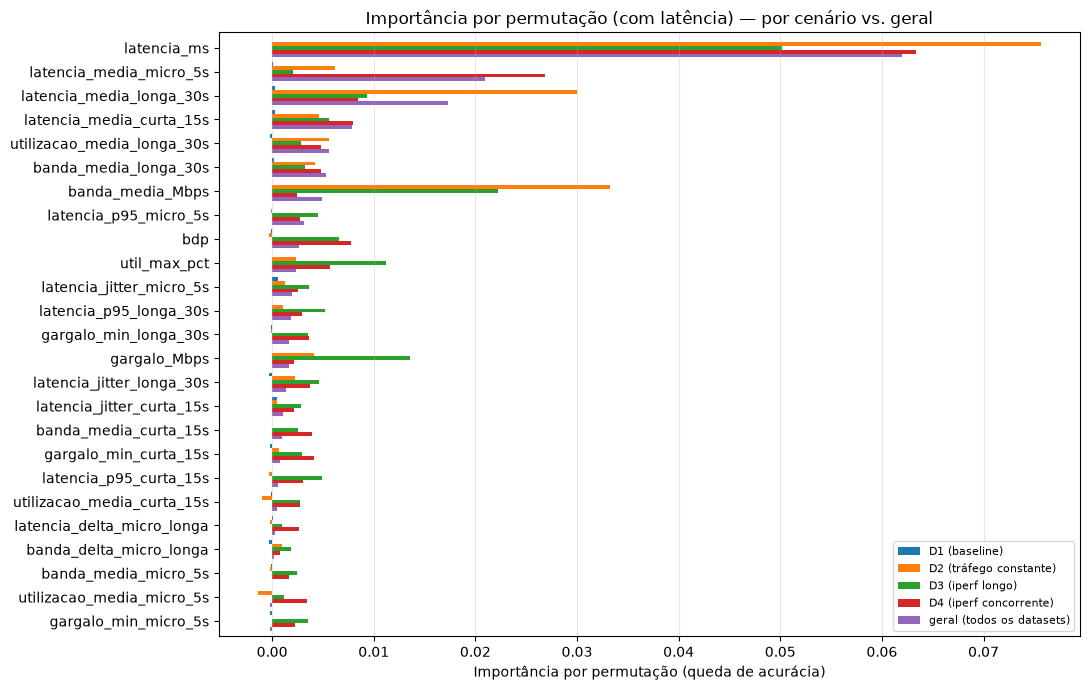

In [60]:
fig, ax = plt.subplots(figsize=(11, 7))
comparacao_cenarios_cl.plot.barh(ax=ax, width=0.8)
ax.set_xlabel('Importância por permutação (queda de acurácia)')
ax.set_title('Importância por permutação (com latência) — por cenário vs. geral')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### MDI por cenário e resultado geral (com latência)

Mesma comparação de MDI por cenário feita na análise sem latência, agora com
o conjunto de 25 features. Espera-se que `latencia_ms` e demais features de
latência dominem o MDI em todos os cenários, dado o vazamento de rótulo.

In [61]:
importancia_mdi_cl = pd.Series(modelo_cl.feature_importances_, index=candidatas_com_latencia)

comparacao_cenarios_mdi_cl = pd.DataFrame(importancias_mdi_por_cenario_cl)
comparacao_cenarios_mdi_cl['geral (todos os datasets)'] = importancia_mdi_cl
comparacao_cenarios_mdi_cl = comparacao_cenarios_mdi_cl.sort_values('geral (todos os datasets)', ascending=False)

comparacao_cenarios_mdi_cl

,D1 (baseline),D2 (tráfego constante),D3 (iperf longo),D4 (iperf concorrente),geral (todos os datasets)
banda_media_Mbps,0.093421,0.126221,0.112004,0.042090,0.113499
util_max_pct,0.068780,0.102497,0.097148,0.056235,0.106745
gargalo_Mbps,0.054132,0.103741,0.094864,0.048586,0.100781
latencia_ms,0.001280,0.112828,0.082754,0.137185,0.096522
bdp,0.010316,0.047218,0.050920,0.090214,0.061775
latencia_media_micro_5s,0.010495,0.053072,0.038254,0.065651,0.041939
utilizacao_media_micro_5s,0.054301,0.016664,0.023472,0.033642,0.039536
latencia_media_longa_30s,0.004192,0.063878,0.045336,0.039592,0.035794
latencia_p95_micro_5s,0.001024,0.034496,0.029988,0.048457,0.034455
latencia_media_curta_15s,0.004079,0.043061,0.033807,0.044153,0.034220


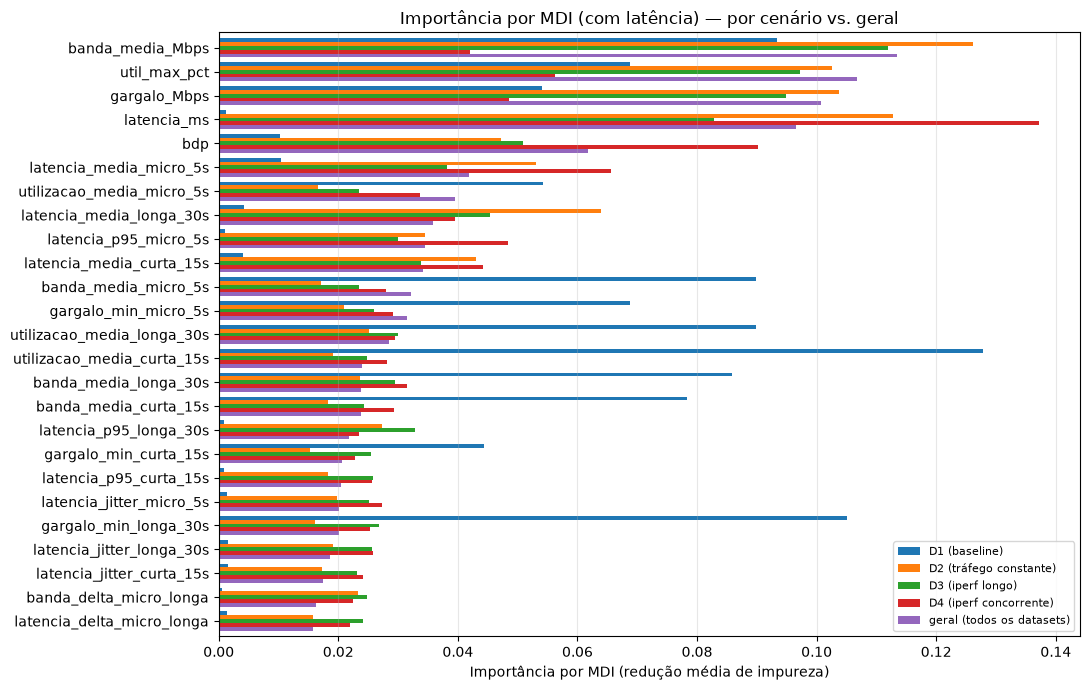

In [62]:
fig, ax = plt.subplots(figsize=(11, 7))
comparacao_cenarios_mdi_cl.plot.barh(ax=ax, width=0.8)
ax.set_xlabel('Importância por MDI (redução média de impureza)')
ax.set_title('Importância por MDI (com latência) — por cenário vs. geral')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### Acurácia por cenário (com latência)

Mesma comparação feita sem latência, agora com as features de latência/bdp
incluídas — permite ver, cenário a cenário, o ganho de acurácia trazido pela
latência frente ao modelo apenas com banda/gargalo.

In [63]:
resumo_acuracia_cl = pd.Series(acuracias_por_cenario_cl)
resumo_acuracia_cl['geral (todos os datasets)'] = acuracia_cl

comparacao_acuracia = pd.DataFrame({
    'sem latência': resumo_acuracia,
    'com latência': resumo_acuracia_cl,
})
comparacao_acuracia['ganho'] = comparacao_acuracia['com latência'] - comparacao_acuracia['sem latência']
comparacao_acuracia

,sem latência,com latência,ganho
D1 (baseline),0.993741,0.993741,0.000000
D2 (tráfego constante),0.836501,0.881185,0.044684
D3 (iperf longo),0.805878,0.840396,0.034518
D4 (iperf concorrente),0.815301,0.863898,0.048596
geral (todos os datasets),0.845543,0.890286,0.044744


### Onde as features de banda ficam no ranking combinado

Isola, dentro do ranking completo (com latência), a posição das features de
banda/gargalo — mostrando quanto do espaço de importância elas ainda ocupam
mesmo competindo diretamente com a latência.

In [64]:
ranking_completo = ordem_perm_cl.rank(ascending=False).astype(int)
posicoes_banda = ranking_completo[[c for c in candidatas_com_latencia
                                    if not c.startswith('latencia_') and c != 'bdp']]

print(f"acurácia sem latência : {acuracia_fi:.4f}  ({len(candidatas)} features)")
print(f"acurácia com latência : {acuracia_cl:.4f}  ({len(candidatas_com_latencia)} features)")
print(f"ganho de acurácia      : {acuracia_cl - acuracia_fi:+.4f}")
print()
print("posição das features de banda no ranking combinado (1 = mais importante):")
posicoes_banda.sort_values().to_frame('posição no ranking')

acurácia sem latência : 0.8455  (13 features)
acurácia com latência : 0.8903  (25 features)
ganho de acurácia      : +0.0447

posição das features de banda no ranking combinado (1 = mais importante):


,posição no ranking
utilizacao_media_longa_30s,5
banda_media_longa_30s,6
banda_media_Mbps,7
util_max_pct,10
gargalo_min_longa_30s,13
gargalo_Mbps,14
banda_media_curta_15s,17
gargalo_min_curta_15s,18
utilizacao_media_curta_15s,20
banda_delta_micro_longa,22


## 10. Resumo e conclusões

### O que foi feito

A análise partiu do conjunto consolidado de todos os 8 datasets elegíveis
(`completo`, Seção 7 — 117.718 registros, 4 rotas por dataset), com
`melhor_rota` como alvo. Um `RandomForestClassifier` (300 árvores) foi
treinado em split estratificado 80/20, e a importância de cada feature foi
medida por dois métodos complementares: **MDI** (redução de impureza,
calculada no treino) e **importância por permutação** (queda de acurácia ao
embaralhar cada coluna no teste, 10 repetições). A análise foi repetida
também separadamente por cenário de tráfego (`D1`/`D1b` a `D4`/`D4b`), tanto
excluindo quanto incluindo as features de latência.

### Features eliminadas e motivo

| feature(s) removida(s) | motivo da exclusão |
|---|---|
| `latencia_*` (p95, jitter, média em todas as janelas) e `latencia_ms` | Definem `melhor_rota` por construção (`melhor_rota = argmin(latencia_ms)`), então dominariam a importância trivialmente sem agregar informação — ver "Vazamento no alvo" na Seção 11. |
| `bdp` | Calculado como `gargalo_Mbps × latencia_ms`, herda o mesmo vazamento por incorporar `latencia_ms` diretamente na fórmula. |
| `dataset_id`, `run_id`, `rota_id`, `ts_epoch`, `datetime_utc`, `tempo_relativo_s` | Identificadores e marcações temporais/de execução, não sinais de rede — mantê-los correlacionaria o modelo a artefatos da coleta (ex.: qual dataset ou run gerou a linha) em vez do comportamento da rede. |
| Colunas de janela integralmente nulas no corte atual | Removidas dinamicamente (`base[c].notna().any()`) — nenhuma das 13 features de banda restantes caiu nessa condição no conjunto completo, mas o filtro protege reexecuções com subconjuntos menores de dados. |

Restaram **13 features**, todas derivadas de banda/gargalo/utilização nas
métricas instantâneas e nas três janelas (`micro`=5s, `curta`=15s,
`longa`=30s).

### Conclusão e interpretação dos resultados

- **Acurácia de 84,6%** prevendo a rota de menor latência **sem usar
  qualquer feature de latência**, apenas com sinais de banda/gargalo — indício
  de que o gargalo de banda por si só carrega bastante informação sobre qual
  caminho está mais congestionado, embora não seja perfeitamente equivalente à
  latência (daí a diferença dos 100% obtidos ao incluir `latencia_ms`).
- **`banda_media_Mbps` domina os dois rankings** (1º lugar em MDI e em
  permutação, com folga): a banda média entre as interfaces do caminho é o
  sinal instantâneo mais informativo, mais até que o próprio gargalo mínimo.
- **MDI e permutação divergem na posição intermediária**: MDI privilegia
  `gargalo_Mbps` e `util_max_pct` (2º-3º lugar), enquanto a permutação
  privilegia as versões em janela do gargalo (`gargalo_min_longa/curta/micro`,
  2º-4º lugar). Isso é consistente com o viés conhecido do MDI a favor de
  features de alta cardinalidade/variância (as métricas instantâneas têm mais
  valores distintos que os agregados de janela) — a permutação, medindo o
  impacto real na acurácia, é a referência mais confiável aqui.
- **Contexto temporal importa mais que o instante isolado para o gargalo**:
  as três variantes de `gargalo_min_{janela}` aparecem entre as 4 mais
  importantes por permutação, sugerindo que a *tendência recente* do gargalo
  (não apenas seu valor pontual) ajuda o modelo a diferenciar rotas.
- **A importância varia por cenário de tráfego**: repetindo a análise
  separadamente por par de datasets (`D1`/`D1b` a `D4`/`D4b`), o padrão muda
  substancialmente entre cenários. Em `D1` (baseline, sem tráfego de fundo) a
  acurácia já é de 99,4% e, ainda assim, várias features mantêm importância
  por permutação comparável (ou até superior) à dos demais cenários — por
  exemplo, `gargalo_min_micro_5s` (0,108) e `banda_media_Mbps` (0,109) — o que
  indica que mesmo com banda quase constante (~100 Mbps o tempo todo) existem
  diferenças residuais sistemáticas entre rotas que o RandomForest consegue
  explorar. Já em `D2` (tráfego constante), `banda_media_Mbps` concentra a
  maior parte da importância (0,190, acima da média geral de 0,154); em
  `D3`/`D4` (fluxos iperf), a importância se distribui mais entre
  `gargalo_min_{janela}` e `util_max_pct`, coerente com a natureza intermitente
  desses cenários — em `D4`, por exemplo, `gargalo_min_longa_30s` (0,092) e
  `gargalo_min_curta_15s` (0,089) superam `banda_media_Mbps` (0,065). Isso
  confirma que a importância "geral" (todos os datasets combinados) é uma
  média que mistura regimes com padrões distintos entre si.
- **Interpretação com cautela**: como discutido na próxima seção, a
  correlação contemporânea entre banda e latência (ambas reagem ao mesmo
  congestionamento) significa que esta importância reflete associação, não
  necessariamente uma relação preditiva utilizável antes do fato consumado.
- **Incluir latência eleva a acurácia geral para 89,0%** (25 features, ante
  84,6% com 13 features de banda apenas) — um ganho de 4,5 pontos percentuais,
  não os 100% que uma dependência determinística perfeita sugeriria à
  primeira vista. `latencia_ms` domina isoladamente a importância por
  permutação nesse cenário combinado (0,062, cerca de 3× a segunda posição),
  mas `banda_media_Mbps`, `gargalo_Mbps` e `util_max_pct` continuam entre as
  10 mais importantes por MDI mesmo competindo diretamente com toda a família
  de features de latência — evidência adicional de que carregam sinal
  complementar, não apenas redundante.

## 11. Limitações

**Correção de unidade não aplicada aqui.** Diferente de `Feature_Store_Telemetria.ipynb`,
que reprocessa a partir de `banda_raw_rota_*.csv` cru, os datasets/D* já foram
gerados por uma versão anterior do protótipo; `banda.bwm` é a captura bruta do
`bwm-ng`, então a mesma correção de unidade (bytes/s → Mbps decimal, sem passar
por Mibit/s) se aplica igualmente aqui. As pequenas diferenças residuais frente
a `banda_rota_*.txt` (na ordem de poucos Mbps em cenários com tráfego
concorrente) refletem o mesmo efeito de arredondamento documentado no notebook
de referência, não um erro de reprocessamento.

**Volume por dataset.** Cada conjunto cobre uma execução de aproximadamente uma
hora (3600–3850 s úteis por rota), muito maior que a coleta de referência (30 s),
mas ainda uma única execução por cenário — não há repetições que permitam
estimar variância entre execuções do mesmo cenário.

**Vazamento no alvo.** A coluna `melhor_rota` permanece função determinística
da latência em todos os datasets, pela mesma razão descrita no notebook de
referência.

**Feature importance com vazamento controlado, mas não eliminado.** Mesmo
excluindo `latencia_*` e `bdp`, features de banda no mesmo instante (`gargalo_Mbps`,
`banda_media_Mbps`) ainda podem carregar parte da mesma causalidade que gera a
latência mais baixa (ex.: link congestionado eleva latência e reduz banda
simultaneamente), então a importância observada reflete correlação
contemporânea, não necessariamente uma relação causal ou preditiva
"antecedente".